# DSCI 631 Final Project EDA

Group 2\
Leland Weeks\
lhw22@drexel.edu\
June 2026

### Board Game Ratings Using BoardGameGeek Data

**Source:** https://www.kaggle.com/datasets/threnjen/board-games-database-from-boardgamegeek

This notebook performs full exploratory data analysis in support of three research questions:
1. What games are overrated and underrated?
2. What features make a boardgame enjoyable?
3. What level of complexity makes a game successful within a genre?

### Files

| File | Description | Usage | 
|------|-------------|-------|
| `games.csv` | Core file containing all primary features and target variables | Needed to answer all 3 questions
| `mechanics.csv` | Game mechanics like `Dice Rolling`, `Cooperative Game`) | Feature set for Q2 |
| `themes.csv` | Genres like `Fantasy`, `Science Fiction`, `Horror` | Feature set for Q2 |
| `subcategories.csv` | Game categories like `Card Game`, `Puzzle` | Feature set for Q2 |

### Key Features

- **Numeric features:** `GameWeight`, `MinPlayers`, `MaxPlayers`, `MfgPlayTime`, `NumOwned`, `NumWant`, `NumExpansions`, `YearPublished`, etc.
- **Binary features:** `IsReimplementation`, `Kickstarted`, subcategories `Strategy`, `Thematic`, etc.

### 0. Setup & Load Data

Four source files are keyed on `BGGId`. The features in the mechanics, themes, and subcategories files are all already binary-encoded (one-hot) so the merge adds 373 binary feature columns, to the origianl 48 columns in games file. 

- Imports the actual data loader library used to power the models.
- Merges all 4 csv files into one dataframe with 432 columns (mostly binary one-hot-encoded)

In [290]:
import sys
import os
sys.path.append(os.path.join(os.path.dirname(''), '../src'))

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data import load_data, merge_data

In [292]:
dfs = load_data()

print('Files loaded:')
for key, df in dfs.items():
    print(f'  {key}: {df.shape}')

df = merge_data(dfs)

print('Merged into one dataframe:')
print(f'  {df.shape}')

Files loaded:
  games: (21925, 48)
  mechanics: (21925, 158)
  themes: (21925, 218)
  subcategories: (21925, 11)
Merged into one dataframe:
  (21925, 432)


### 1. Target & Feature Data Summary

#### 1.1 Data Summary

I selected these nine numeric features for analysis because they represent the breadth and depth of data in the dataset. They span game complexity `GameWeight`, player counts `MinPlayers` and `MaxPlayers`, time investment `MfgPlaytime`, and more.

Important target variables to answer the research questions are `AvgRating` and then derivations from `NumOwned` and `NumWant`. 

Summary, in addition to data below, of numeric features
- `AvgRating` target variable has a farily normal distribution
- `NumOwned` std 5294 and mean 1468 means data is heavily skewed, will need log transform
- `MaxPlayers` max 999 may mean unlimited number of players
- `MinPlayers` and `MaxPlayers` have identical percentiles, only diff is because `Maxplayers` skews max 999
- `MfgPlaytime` max 60,000 min, which is ~42 days, an extreme outlier, probably bad data
- `YearPublished` min -3500 is 3500 BC, far negative outlier for very old game

In [339]:
NUMERIC_FEATURES = [
    'AvgRating', 'GameWeight', 'NumOwned', 'NumWant',
    'MinPlayers', 'MaxPlayers', 'MfgPlaytime',
    'NumExpansions', 'YearPublished'
]

CAT_GENRES = [
    'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family',
    'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens'
]

display(df[NUMERIC_FEATURES].describe().round(2))
display(df[CAT_GENRES].describe().round(2))

,AvgRating,GameWeight,NumOwned,NumWant,MinPlayers,MaxPlayers,MfgPlaytime,NumExpansions,YearPublished
count,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00
mean,6.42,1.98,1467.85,41.69,2.01,5.71,90.51,1.38,1985.49
std,0.93,0.85,5294.12,117.26,0.69,15.01,529.66,7.70,212.49
min,1.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-3500.00
25%,5.84,1.33,150.00,3.00,2.00,4.00,25.00,0.00,2001.00
50%,6.45,1.97,320.00,9.00,2.00,4.00,45.00,0.00,2011.00
75%,7.05,2.53,899.00,28.00,2.00,6.00,90.00,1.00,2017.00
max,9.91,5.00,166497.00,2031.00,10.00,999.00,60000.00,525.00,2021.00


,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
count,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00,21925.00
mean,0.06,0.11,0.16,0.11,0.01,0.05,0.03,0.04
std,0.23,0.31,0.37,0.31,0.12,0.22,0.17,0.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


#### 1.2 Missing Values

In short, missing values will not be an serious hurdle due to
- None of the numeric features have missing values
- 5 features have missing values, none of which are in numeric features
- `Family` is missing almost 3/4 of it's data, potentially unusable, canidate for impute
- `LanguageEase` and `ComAgeRec` have significant data lapses, about 25%, I'll see if I can drop
- `ImagePath` and `Description` hae negligible missing data, could just drop those rows

In [296]:
# missing nulls in order of most missing
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Missing Values:')
print(f'{nulls}')

Missing Values:
Family          15262
LanguageEase     5891
ComAgeRec        5530
ImagePath          17
Description         1
dtype: int64


### 2. Target & Feature Distributions

#### 2.1. Most Important for Analysis: AvgRating

With normal distribution and no missing values, analysis is clean. No skew to slight skew means no transformationn is necessary and standard linear regressionn modells will work well. Will consider standard linear regression, and Lasso, Ridge, etc. 

- `AvgRating` is used as the target variable in research questions 1 and 2
- Since the distribution is normal, linear regression will work well

Mean:  6.42
Std:   0.93
Skew: -0.31
Range: 1.04 - 9.91


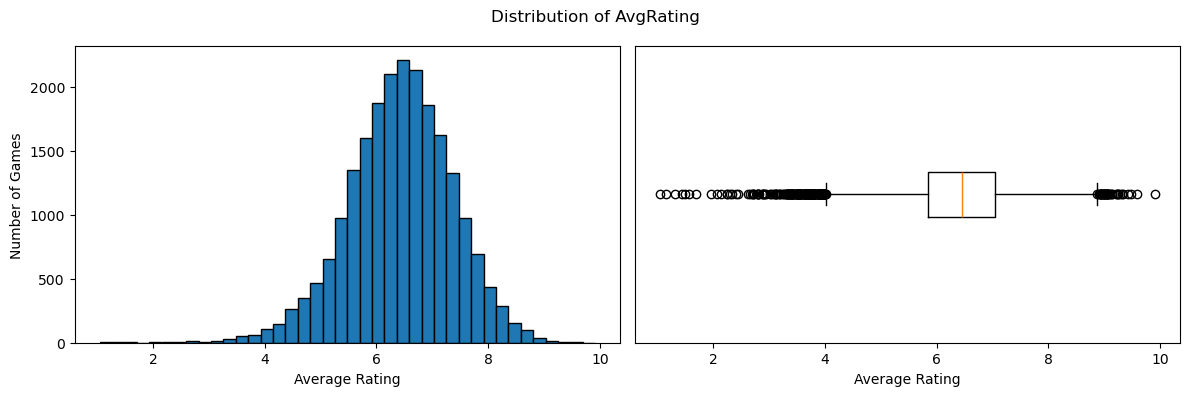

In [299]:

data = df['AvgRating'].dropna()

print(f'Mean:  {data.mean():.2f}')
print(f'Std:   {data.std():.2f}')
print(f'Skew: {data.skew():.2f}')
print(f'Range: {data.min():.2f} - {data.max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution of AvgRating')
axes[0].hist(data, bins=40, edgecolor='black')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Games')
axes[1].boxplot(data, vert=False)
axes[1].set_xlabel('Average Rating')
axes[1].set_yticks([])
plt.tight_layout()
plt.show()
plt.close()

#### 2.1. NumOwned & Rating for Primary Research Question

`NumOwned` represents how many BoardGameGeekk users own a specific game.
- Data is heavily skewed, needs normalization via log1p


Skew:  12.52
Log1p:  0.76


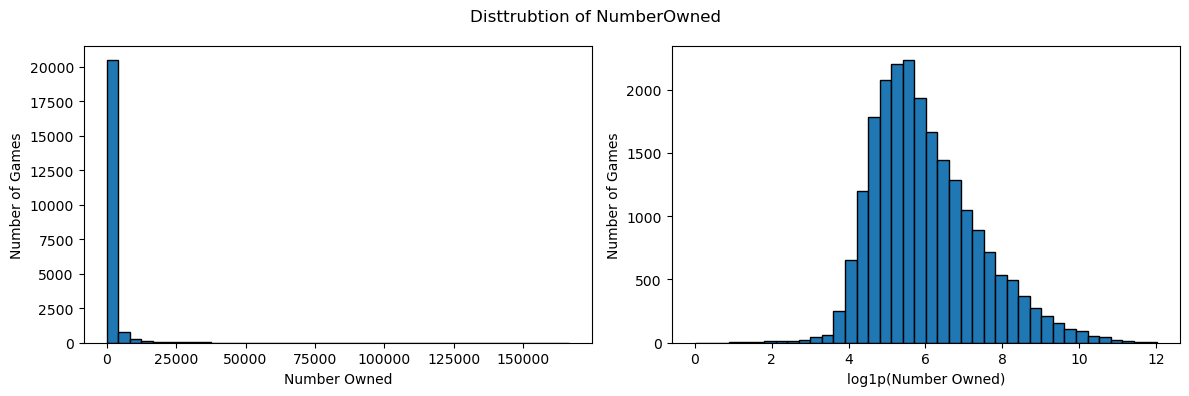

In [303]:
data = df['NumOwned'].dropna()
data_log = np.log1p(data)

print(f'Skew:  {data.skew():.2f}')
print(f'Log1p:  {data_log.skew():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data, bins=40, edgecolor='black')
fig.suptitle('Distrubtion of NumberOwned')
axes[0].set_xlabel('Number Owned')
axes[0].set_ylabel('Number of Games')
axes[1].hist(data_log, bins=40, edgecolor='black')
axes[1].set_xlabel('log1p(Number Owned)')
axes[1].set_ylabel('Number of Games')
plt.tight_layout()
plt.show()
plt.close()


#### 2.2 GameWeight needed exclusively for research question #3

`GameWeight` representns complexity by genre. According to the data, most games are light-to-medium complexity and high complexity games 

Mean: 1.98
Std:  0.85
Skew: 0.40


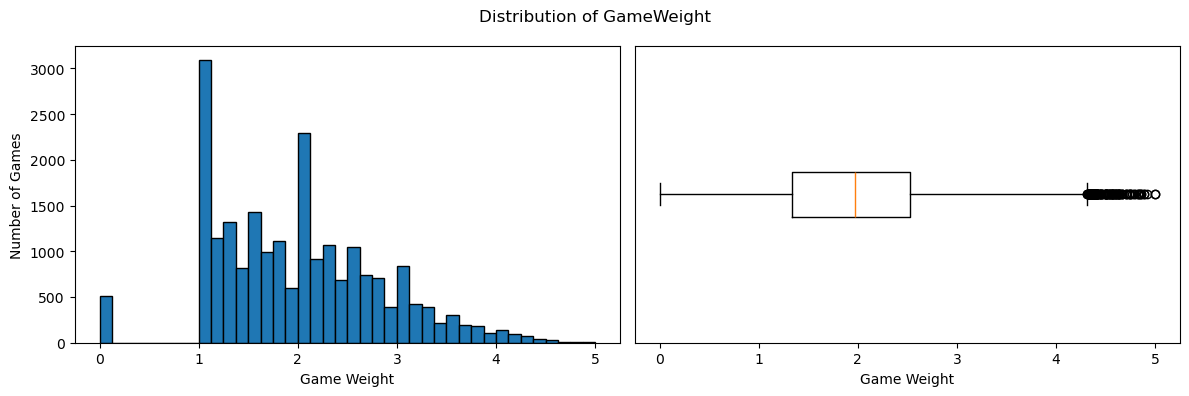

In [306]:
data = df['GameWeight'].dropna()

print(f'Mean: {data.mean():.2f}')
print(f'Std:  {data.std():.2f}')
print(f'Skew: {data.skew():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution of GameWeight')
axes[0].hist(data, bins=40, edgecolor='black')
axes[0].set_xlabel('Game Weight')
axes[0].set_ylabel('Number of Games')
axes[1].boxplot(data, vert=False)
axes[1].set_xlabel('Game Weight')
axes[1].set_yticks([])
plt.tight_layout()
plt.show()
plt.close()

#### 

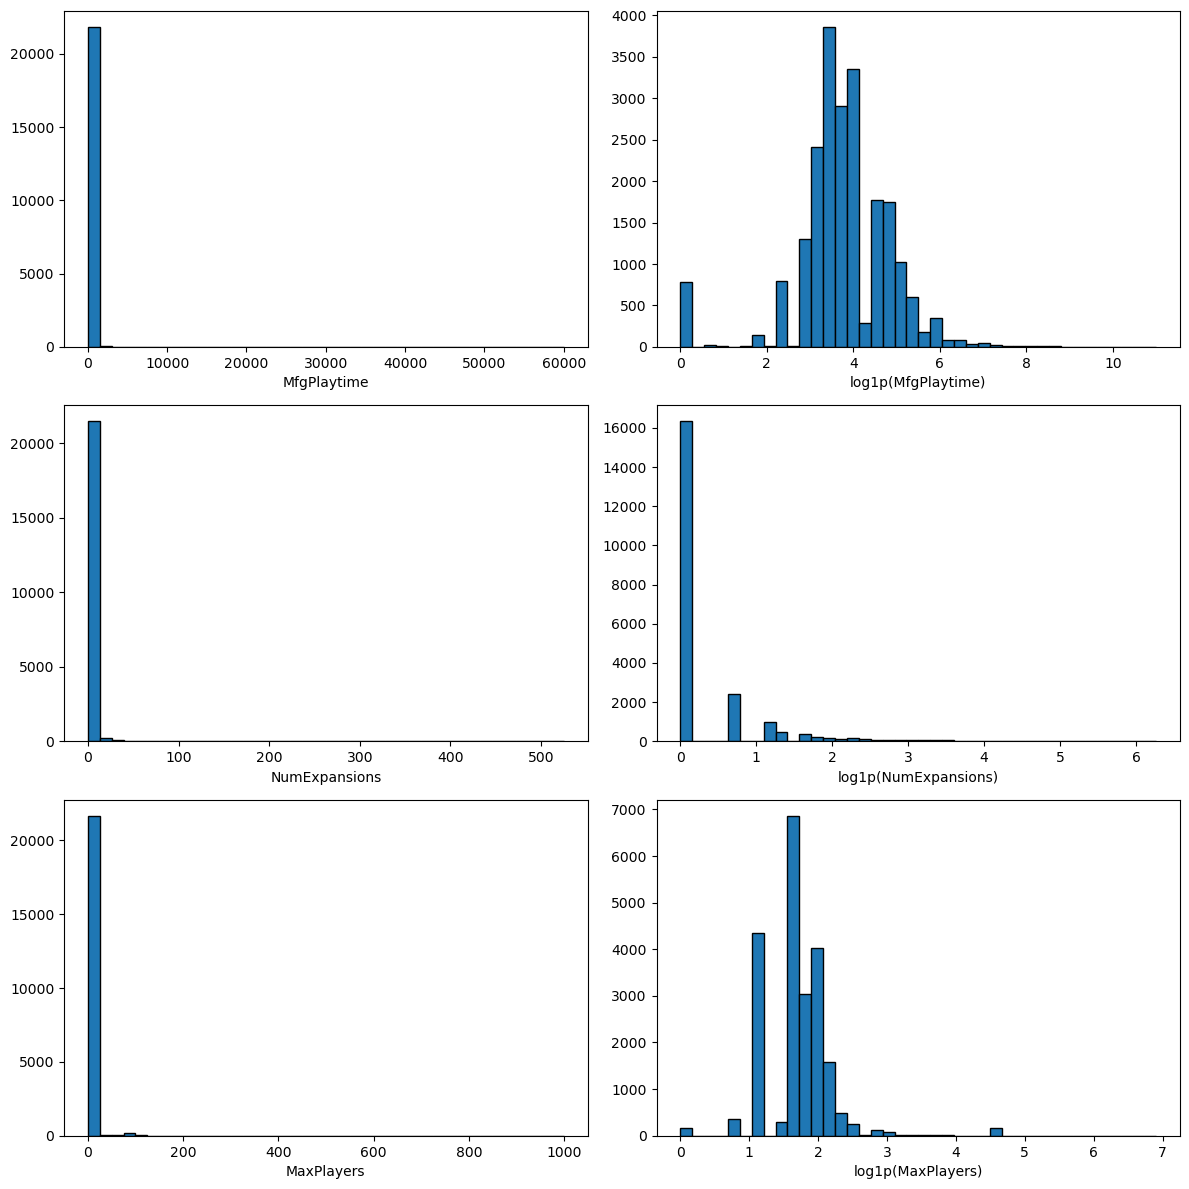

In [309]:
# numeric features disribution
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

data = df['MfgPlaytime'].dropna()
data_log = np.log1p(data)
axes[0, 0].hist(data, bins=40, edgecolor='black')
axes[0, 0].set_xlabel('MfgPlaytime')
axes[0, 1].hist(data_log, bins=40, edgecolor='black')
axes[0, 1].set_xlabel('log1p(MfgPlaytime)')

data = df['NumExpansions'].dropna()
data_log = np.log1p(data)
axes[1, 0].hist(data, bins=40, edgecolor='black')
axes[1, 0].set_xlabel('NumExpansions')
axes[1, 1].hist(data_log, bins=40, edgecolor='black')
axes[1, 1].set_xlabel('log1p(NumExpansions)')

data = df['MaxPlayers'].dropna()
data_log = np.log1p(data)
axes[2, 0].hist(data, bins=40, edgecolor='black')
axes[2, 0].set_xlabel('MaxPlayers')
axes[2, 1].hist(data_log, bins=40, edgecolor='black')
axes[2, 1].set_xlabel('log1p(MaxPlayers)')

plt.tight_layout()
plt.show()
plt.close()

### 3. Correlation

#### 3.1 Heatmap

`AvgRating` with other feature variables shows overall high correlationn.

- `GameWeight` is the strongest predictor with a correlatioon of 0.478 
- `NumWant`'s correlation of 0.328 is more predictive than `NumOwnend` at 0.178, which implies wanting a game implies higher quality more than actual ownenrship
- `NumComments` returns NaN — it is all zeros in this dataset and carries no signal

The heatmap confirms correlation between `GameWeight`, `NumWant`, and `NumOwned`. This multi-collinearity is relevant for research question 2.

Correlation with AvgRating:


,AvgRating
GameWeight,0.478
NumWant,0.328
NumOwned,0.178
NumExpansions,0.154
MfgPlaytime,0.093
YearPublished,0.079
MaxPlayers,-0.041
MinPlayers,-0.173


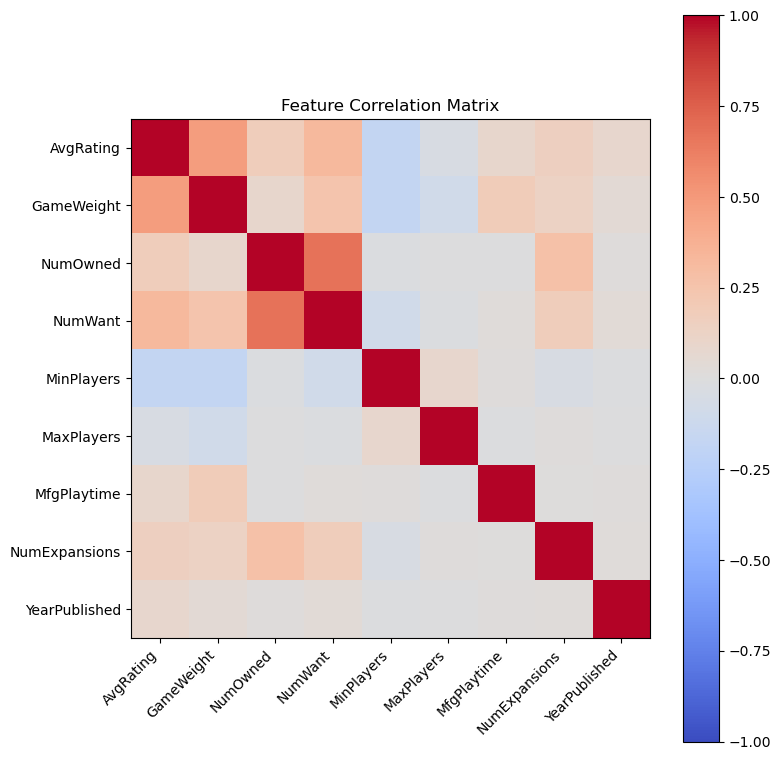

In [335]:
corrs = df[NUMERIC_FEATURES].corr()[['AvgRating']].drop('AvgRating')
corrs = corrs.sort_values('AvgRating', ascending=False)

print('Correlation with AvgRating:')
display(corrs.round(3))

corr = df[NUMERIC_FEATURES].corr()

fig, axes = plt.subplots(figsize=(8,8))
im = axes.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes)

axes.set_xticks(range(len(corr.columns)))
axes.set_yticks(range(len(corr.columns)))
axes.set_xticklabels(corr.columns, rotation=45, ha='right')
axes.set_yticklabels(corr.columns)

axes.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
plt.close()

#### 3.2 Scatterplot

For question 1, `AvgRating` per `NumOwned` determines if a game is overrated or underrated, which is a classification question.

- Specifically, a low `AvgRating` and high `NumOwned` indicates overrated while a high `AvgRating` and low `NumOwned` indicates underrated.
- Will need to determine how to split the classes (below)
    - For example: when `AvgRating` / `NumOwned` is relatively large will indicate the overrated class
    - But need to determine most meaningful boundary between classes

Correlation (log NumOwned vs AvgRating): 0.296


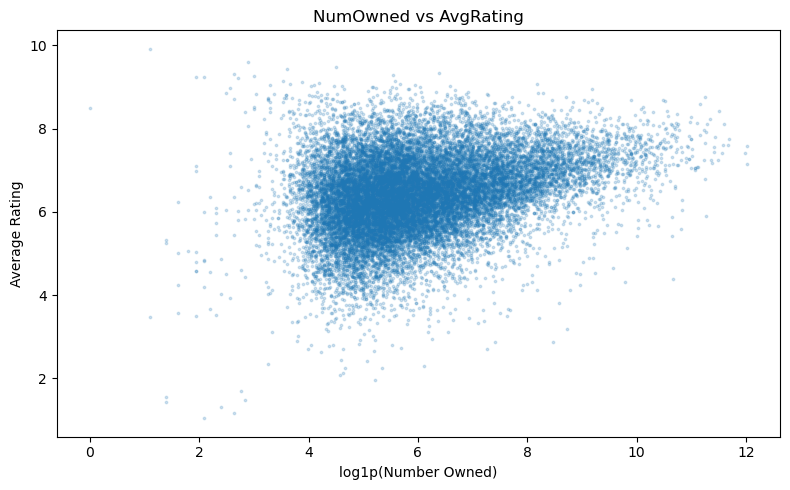

In [315]:
plot_df = df[['NumOwned', 'AvgRating']].dropna()
x = np.log1p(plot_df['NumOwned'])
y = plot_df['AvgRating']

print(f'Correlation (log NumOwned vs AvgRating): {np.corrcoef(x, y)[0, 1]:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.2, s=3)
plt.title('NumOwned vs AvgRating')

plt.xlabel('log1p(Number Owned)')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()
plt.close()

### 4. Rating Class Distribution

Using `AvgRating / NumOwned` as the boundary between classes, and then `pd.qcut` to bin into the separate classes. Equal-sized bins ensures balanced classes, avoids the imbalanced classification problem covered in Assignment 2.

In [333]:
class_df = df[['NumOwned', 'AvgRating']].dropna().copy()
class_df['rating_class'] = class_df['AvgRating'] / class_df['NumOwned']
class_df['rating_class'] = pd.qcut(
    class_df['rating_class'], q=3,
    labels=['overrated', 'middle_rated', 'underrated']
)

print('Class distribution:')
print(class_df['rating_class'].value_counts())

Class distribution:
rating_class
middle_rated    7309
overrated       7308
underrated      7308
Name: count, dtype: int64


### 5. GameWeight by Genre for question 3

#### 5.1 Game Counts by Genre

Games can belong to multiple genres simultaneously
- Strategy and Family have the most games
- Party and Children's have the fewest

Cat:War          3530
Cat:Strategy     2319
Cat:Family       2316
Cat:Thematic     1224
Cat:Abstract     1115
Cat:Childrens     881
Cat:Party         640
Cat:CGS           303


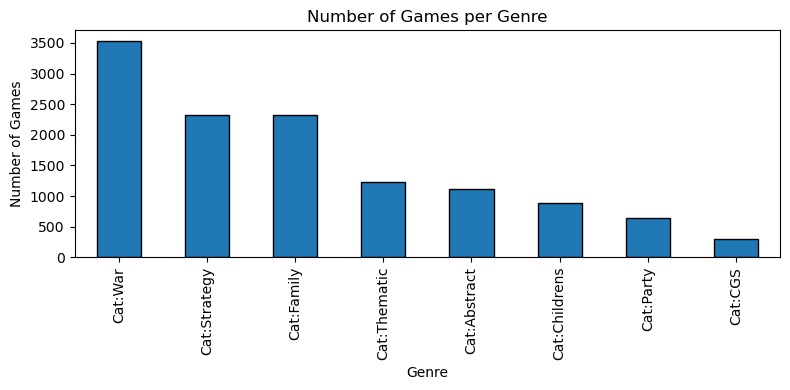

In [325]:
genre_counts = {}
for genre in CAT_GENRES:
    genre_counts[genre] = df[genre].sum()
genre_counts = pd.Series(genre_counts).sort_values(ascending=False)

print(genre_counts.to_string())

plt.figure(figsize=(8, 4))
genre_counts.plot(kind='bar', edgecolor='black')
plt.title('Number of Games per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()
plt.close()

#### 5.2 Average Rating by Genre

- War and Strategy games tend to be rated higher on average
- Party and Children's games rate lower
- The baseline difference in rating by genre is important for question 3

Cat:Strategy     6.954
Cat:War          6.880
Cat:Thematic     6.805
Cat:Family       6.424
Cat:CGS          6.398
Cat:Party        6.291
Cat:Abstract     6.237
Cat:Childrens    5.528


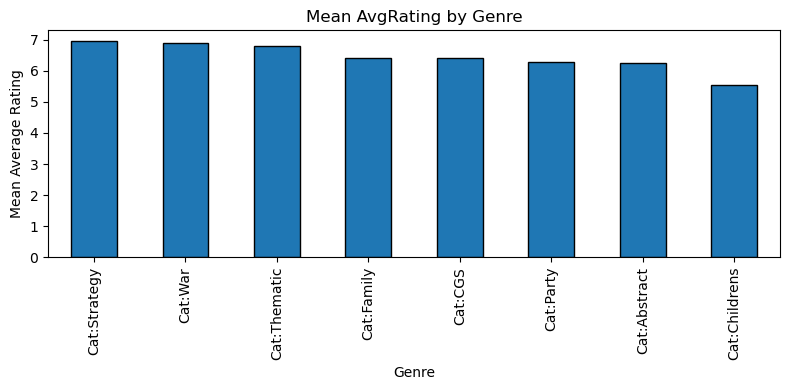

In [328]:
genre_ratings = {}
for genre in CAT_GENRES:
    genre_df = df[df[genre] == 1]
    genre_ratings[genre] = genre_df['AvgRating'].dropna().mean()
genre_ratings = pd.Series(genre_ratings).sort_values(ascending=False)

print(genre_ratings.round(3).to_string())

plt.figure(figsize=(8, 4))
genre_ratings.plot(kind='bar', edgecolor='black')
plt.title('Mean AvgRating by Genre')
plt.xlabel('Genre')
plt.ylabel('Mean Average Rating')
plt.tight_layout()
plt.show()
plt.close()


### 7. Key Observations

**Q1 — What games are overrated and underrated?**
- `NumOwned` is extremely right-skewed — need to apply log1p
- Positive correlation between ownership and rating
- Equal-bin `pd.qcut` produces balanced classes

**Q2 — What features make a boardgame enjoyable?**
- `AvgRating` is approximately normal — great regression target
- `GameWeight` is the strongest predictor
- `MfgPlaytime`, `NumExpansions`, `MaxPlayers` are severely right-skewed — log1p applied
- `YearPublished` has extreme negative skew — log does not help, used as-is
- StandardScaler applied before linear models
- 400+ binary features from mechanics/themes/subcategories

**Q3 — Does complexity predict rating within a genre?**
- `GameWeight` varies across genres
- Thematic and Strategy genres are the strongest `GameWeight` signal
- Party games show zero complexity is not predictive
- Genre-level differences justify regression modeling